# Geographical filter results

## Python library imports

In [1]:
import Common
import json
import mgrs
import matplotlib.ticker 
import matplotlib.pyplot as pyplt
import numpy as np
import pandas as pd
import os.path

## Parse Flora-On information 

Geographical observation records for Continental Portugal are available from [Flora-On](https://flora-on.pt) as CSV files. These CSV files are available in the `flora-on/geographic-records.zip` archive which contains one CSV file per species. Two fields in the CSV format yield the MGRS coordinate (e.g., `MC6829S`); the fields are (1) `Quadrícula` (grid cell, e.g., `MC68`),  and (2) `Zona UTM` (UTM zone, e.g., `29S`). The `mgrs` Python library is used to convert these to WGS84 coordinates (latitude and longitude). 

In [8]:
MGRS_HANDLER = mgrs.MGRS() # used for MGRS > WGS84 conversion

def parse_floraOn_file(path, species):
  try:
    data = pd.read_csv('%s/%s.csv' % (path, species.replace(' ','_')), sep=';')
    data['MGRS'] = data['Zona UTM'].astype(str) + data['Quadrícula'].astype(str) 
    coordinates = { MGRS_HANDLER.toLatLon(x.MGRS) for x in data.itertuples() }
  except:
    coordinates = []
  return list(sorted(coordinates))

set_of_species = pd.read_csv('../floralens/species_genus_family.tsv', sep='\t')['species']
floraOnCoordRecords = dict()
for s in set_of_species:
  cset = parse_floraOn_file('../flora-on/geographic-records', s)
  if cset != []:
    floraOnCoordRecords[s] = cset

# print(floraOnCoordRecords['Acacia dealbata'])
print(len(floraOnCoordRecords.keys()), 'species covered by Flora-On geographic records')

1643 species covered by Flora-On geographic records


## Read Floralens dataset and filter  images of interest

Filtered images meet 3 conditions: (1) are in the test set; (2) have a GBIFid; and (3) correspond to species covered in the Flora-On geographic records.

In [5]:
data = pd.read_csv('../floralens/floralens_dataset.tsv', sep='\t')
data = data[data.set == 'TEST']  # just TEST images
data = data[data.repos != 'FloraOn'] # No GBIF id for FloraOn images
data = data[['gbif_id','species','filename', 'url']]
data['gbif_id'] = data['gbif_id'].astype(int)
species_covered = pd.DataFrame(floraOnCoordRecords.keys(), columns=['species'])
data = data.merge(species_covered, on=['species'])
data

,gbif_id,species,filename,url
0,1945424512,Acacia dealbata,Acacia_dealbata_1945424512_1.jpg,https://storage.googleapis.com/floraondata/ina...
1,2974327900,Acacia dealbata,Acacia_dealbata_2974327900_1.jpg,https://storage.googleapis.com/floraondata/Pla...
2,1946199420,Acacia dealbata,Acacia_dealbata_1946199420_3.jpg,https://storage.googleapis.com/floraondata/ina...
3,1945436102,Acacia dealbata,Acacia_dealbata_1945436102_1.jpg,https://storage.googleapis.com/floraondata/ina...
4,1805367892,Acacia dealbata,Acacia_dealbata_1805367892_1.jpg,https://storage.googleapis.com/floraondata/ina...
...,...,...,...,...
27205,2242774794,Zostera noltii,Zostera_noltii_2242774794_1.jpg,https://storage.googleapis.com/floraondata/ina...
27206,1972305757,Zostera noltii,Zostera_noltii_1972305757_1.jpg,https://storage.googleapis.com/floraondata/Obs...
27207,1931477974,Zostera noltii,Zostera_noltii_1931477974_1.jpg,https://storage.googleapis.com/floraondata/ina...
27208,3112502324,Zostera noltii,Zostera_noltii_3112502324_2.jpg,https://storage.googleapis.com/floraondata/ina...


## Determine images in Continental Portugal

We consider GBIF information for Portugueses observations in the source datasets, 
to determine images corresponding to Continental Portugal and their respective coordinates.


In [15]:
# Read GBIF information
gdata = pd.read_csv('../floralens/gbif/pt_observations.csv', sep='\t')
# Merge with Floralens test data
mdata = data.merge(gdata[['gbif_id','decimalLatitude','decimalLongitude']], on='gbif_id')
mdata = mdata[mdata.decimalLongitude > -9.50055556] # only Continental Portugal (East of Cabo da Roca)
mdata

/tmp/ipykernel_6758/1485248038.py:2: DtypeWarning: Columns (14,16,36,37,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  gdata = pd.read_csv('../floralens/gbif/pt_observations.csv', sep='\t')


,gbif_id,species,filename,url,decimalLatitude,decimalLongitude
0,1946199420,Acacia dealbata,Acacia_dealbata_1946199420_3.jpg,https://storage.googleapis.com/floraondata/ina...,40.695112,-8.621217
1,1805367892,Acacia dealbata,Acacia_dealbata_1805367892_1.jpg,https://storage.googleapis.com/floraondata/ina...,39.914196,-8.624933
2,1850964436,Acacia dealbata,Acacia_dealbata_1850964436_1.jpg,https://storage.googleapis.com/floraondata/ina...,40.278405,-7.514628
3,1944416000,Acacia dealbata,Acacia_dealbata_1944416000_2.jpg,https://storage.googleapis.com/floraondata/ina...,40.342116,-8.094790
4,2540880638,Acacia dealbata,Acacia_dealbata_2540880638_3.jpg,https://storage.googleapis.com/floraondata/ina...,40.713386,-8.100403
...,...,...,...,...,...,...
3270,2465253811,Zostera noltii,Zostera_noltii_2465253811_1.jpg,https://storage.googleapis.com/floraondata/ina...,40.619225,-8.738635
3271,1847631992,Zostera noltii,Zostera_noltii_1847631992_1.jpg,https://storage.googleapis.com/floraondata/ina...,40.615703,-8.739737
3272,2242774794,Zostera noltii,Zostera_noltii_2242774794_1.jpg,https://storage.googleapis.com/floraondata/ina...,37.154772,-7.549553
3273,1931477974,Zostera noltii,Zostera_noltii_1931477974_1.jpg,https://storage.googleapis.com/floraondata/ina...,37.119085,-7.620989


In [16]:
print(len(mdata), 'images for', len(mdata[['species']].drop_duplicates()), 'species')
mdata[['species','gbif_id']].groupby('species').count()

3172 images for 770 species


,gbif_id
species,
Acacia dealbata,12
Acacia longifolia,18
Acacia mearnsii,5
Acacia melanoxylon,14
Acacia pycnantha,5
...,...
Vitis vinifera,1
Vulpia membranacea,1
Xanthium strumarium,2


## Analyse consistency between Flora-On records and GBIF records

We determine the  distance between the observed position in GBIF and the nearest coordinate in the Flora-On records for the species at stake. We derive a CDF plot for the analysis.

In [17]:
def wgs84_distance(lat1, lon1, lat2, lon2):
    # spherical law of cosines, accurate enough for small distances
    # https://www.askpython.com/python/examples/find-distance-between-two-geo-locations
    from math import radians, sin, cos, acos
    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)    
    lon2 = radians(lon2)
    dist = 6371.01 * acos(sin(lat1)*sin(lat2) + cos(lat1)*cos(lat2)*cos(lon1 - lon2))
    return dist
def shortest_distance_in_floraOnCoordRecords(coord_list, lat, lon):
    return sorted([ wgs84_distance(lat, lon, c[0], c[1]) for c in coord_list ])[0]
    
shortest_distances = pd.Series([ 
    shortest_distance_in_floraOnCoordRecords( floraOnCoordRecords[img.species], 
                                              img.decimalLatitude, img.decimalLongitude)
    for img in mdata.itertuples()
])
perc_ref = [90,95,97,99]
print('Percentiles for shortest distances')
for r,p in zip(perc_ref,np.percentile(shortest_distances, perc_ref)):
    print(r,p)

Percentiles for shortest distances
90 12.18888161760673
95 18.883720884248497
97 24.67361417654835
99 42.358480814158945


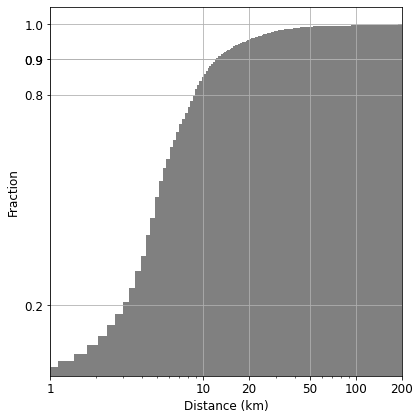

In [20]:
font = {'family' : 'normal',
        'size'   : 12}
pyplt.rc('font', **font)
pyplt.rcParams["figure.figsize"] = (6,6)
plt = shortest_distances.hist(cumulative=True, density=1,  bins=1000, color='gray')
plt.set_xscale("log")
plt.set_xlabel("Distance (km)")
plt.set_ylabel("Fraction")
plt.xaxis.set_major_formatter(matplotlib.ticker.EngFormatter())
plt.set_xticks([1,10,20,50,100,200])
plt.set_yticks([0.2,0.8,0.9,0.9,1.0])
plt.set_xlim([1,200])
plt.get_figure().tight_layout()
plt.get_figure().savefig('plot_images/floraon_gbif_distance_cdf_2.pdf')

## Derive geographic filter results for varying distance thresholds

In [35]:
model_index_to_species = Common.read_floralens_model_labels()

def analyse(mdata, THRESHOLD):
    count = 1
    output_filename = "geo_filter_"+str(THRESHOLD)+".tsv"
    output_file = open(output_filename, "w")
    print('filename\tspecies\trank1\tc1\trank2\tc2\trank3\tc3\trank4\tc4\trank5\tc5', file=output_file)
    for record in mdata.itertuples():
        score_file = '../floralens/detailed-results/' + record.filename + '.score.txt'
        scores = np.array([ float(s.strip()) for s in open(score_file, 'r').readlines() ])
        #print(scores)
        ranks = scores.argsort()[::-1]
        count = 0
        rank = 0
        s = []
        for r in ranks:
            species = model_index_to_species[r]
            if species in floraOnCoordRecords.keys() and \
               shortest_distance_in_floraOnCoordRecords(floraOnCoordRecords[species], 
                                                        record.decimalLatitude, record.decimalLongitude) < THRESHOLD:
                count += 1
                s.append((species,scores[r]))
                if count == 5:
                    break
        #print(s)
        print(record.filename, record.species, s[0][0],s[0][1],
                                               s[1][0],s[1][1],
                                               s[2][0],s[2][1],
                                               s[3][0],s[3][1],
                                               s[4][0],s[4][1], sep='\t', file=output_file)   

    output_file.flush()
    output_file.close()
    return output_filename,pd.read_csv(output_filename,sep='\t')

stats = {
    'threshold': [],
    'top1': [],
    'top5': [],
    'mrr':  []
}
for THRESHOLD in range(20,210,10):
    filename, df = analyse(mdata, THRESHOLD)
    top1_value, top5_value, mrr_value = (Common.top1(df), Common.top5(df), Common.mrr(df))
    stats['threshold'].append(THRESHOLD)
    stats['top1'].append(top1_value)
    stats['top5'].append(top5_value)
    stats['mrr'].append(mrr_value)
    print(THRESHOLD,top1_value, top5_value, mrr_value,filename)

20 0.7616645649432535 0.8896595208070618 0.8145544346364018 geo_filter_20.tsv
30 0.7730138713745272 0.9095208070617906 0.8289092055485497 geo_filter_30.tsv
40 0.7745901639344263 0.9129886506935687 0.8310582177385455 geo_filter_40.tsv
50 0.7708070617906684 0.9120428751576293 0.8281525851197982 geo_filter_50.tsv
60 0.7682849936948297 0.912358133669609 0.826639344262295 geo_filter_60.tsv
70 0.7635561160151324 0.9098360655737705 0.823292349726776 geo_filter_70.tsv
80 0.7610340479192939 0.9092055485498108 0.8218736864228668 geo_filter_80.tsv
90 0.7594577553593947 0.9079445145018915 0.8205390920554855 geo_filter_90.tsv
100 0.7566204287515763 0.9076292559899117 0.8187000840689365 geo_filter_100.tsv
110 0.7566204287515763 0.9066834804539723 0.8179487179487179 geo_filter_110.tsv
120 0.7556746532156369 0.9057377049180327 0.8170292139554435 geo_filter_120.tsv
130 0.7547288776796973 0.905422446406053 0.816335645229088 geo_filter_130.tsv
140 0.7537831021437579 0.9057377049180327 0.8158417402269861 

## Plot variations in comparision to standard results

3172 0.7348675914249685 0.8988020176544766 0.801860025220681


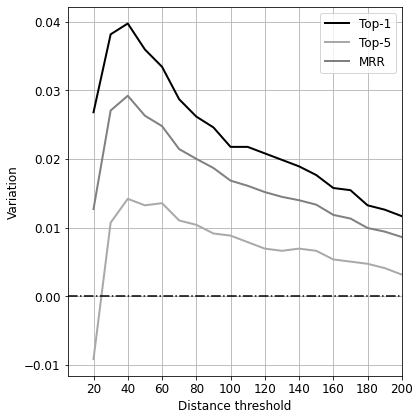

In [36]:
unfiltered_data = pd.read_csv('../floralens/flts_floralens.tsv',sep='\t')
unfiltered_data = unfiltered_data.merge(mdata[['filename','species']], on=['filename','species'])
print(len(unfiltered_data),Common.top1(unfiltered_data), Common.top5(unfiltered_data), Common.mrr(unfiltered_data))
stats_df = pd.DataFrame.from_dict(stats)
stats_df['top1'] = stats_df['top1'] - Common.top1(unfiltered_data)
stats_df['top5'] = stats_df['top5'] - Common.top5(unfiltered_data)
stats_df['mrr'] = stats_df['mrr'] - Common.mrr(unfiltered_data)
stats_df.rename(columns={'top1': 'Top-1','top5': 'Top-5', 'mrr': 'MRR'},inplace=True)
stats_df.set_index('threshold',inplace=True)
plt = stats_df.plot.line(color=['black','darkgray','gray'],linewidth=2)
plt.axhline(y=0, color='black', linestyle='-.')
plt.set_xlim([5, 200])
plt.set_xticks([x for x in range(20,220,20)])
plt.set_xlabel('Distance threshold')
plt.set_ylabel('Variation')
plt.grid()
plt.get_figure().tight_layout()
plt.get_figure().savefig('plot_images/geo_filter_plot.pdf')

In [37]:
print('Max variations')
stats_df.max()

Top-1    0.039723
Top-5    0.014187
MRR      0.029198
dtype: float64

## Analyse fraction of images affected by filter 

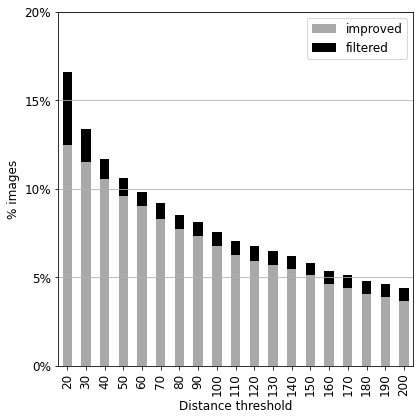

In [41]:
def compute_mrr_column(data):
    data['mrr'] = (data['species'] == data['rank1']).astype(float) + \
                  (data['species'] == data['rank2']).astype(float) / 2 + \
                  (data['species'] == data['rank3']).astype(float) / 3 + \
                  (data['species'] == data['rank4']).astype(float) / 4 + \
                  (data['species'] == data['rank5']).astype(float) / 5

compute_mrr_column(unfiltered_data)
stats = []

total_images = len(unfiltered_data)

for THRESHOLD in range(20,210,10):
    data = pd.read_csv("geo_filter_"+str(THRESHOLD)+".tsv", sep='\t')
    compute_mrr_column(data)
    mdf = data.merge(unfiltered_data, on=['filename','species'], suffixes=('_a', '_b'))
    mdf['changes'] = (mdf['rank5_a'] != mdf['rank5_b']).astype(float) 
    ground_truth_rank_improved = len(mdf[mdf.mrr_a > mdf.mrr_b]) 
    ground_truth_filtered = len(mdf[mdf.mrr_a < mdf.mrr_b])
    other_changes = (len(mdf[mdf.changes > 0]) - ground_truth_rank_improved - ground_truth_filtered) 
    #print(THRESHOLD, ground_truth_rank_improved, ground_truth_filtered, other_changes)
    other_changes *= (100 / total_images)
    ground_truth_rank_improved *= (100 / total_images)
    ground_truth_filtered *= (100 / total_images)
    #print(THRESHOLD, ground_truth_rank_improved, ground_truth_filtered, other_changes)
    stats.append([THRESHOLD, ground_truth_rank_improved, ground_truth_filtered ]) # other_changes])


stats_df = pd.DataFrame(stats, columns=["D","improved","filtered"])
stats_df.set_index("D", inplace=True)
plt=stats_df.plot.bar(stacked=True,color=['darkgray','black'])
#plt.set_xlim([5, 300])
#plt.set_xticks([x for x in range(20,310,20)])
plt.set_xlabel('Distance threshold')
plt.set_ylabel('% images')
#plt.set_yscale('log')
plt.set_yticks([0, 5, 10, 15, 20])
plt.set_ylim([0,20]) #30, 40, 50, 60, 70, 80, 90, 100])
plt.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(decimals=0))
#plt.axhline(y=0, color='black', linestyle='-.')
plt.yaxis.grid()
plt.get_figure().tight_layout()
plt.get_figure().savefig('plot_images/geo_filter_changes_plot.pdf')